In [53]:
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
import fitsio as F
import numpy as np
from astropy.table import Table
import time
import matplotlib.pyplot as plt
import scienceplots
import glob
import re
import treecorr
import healpy as hp
from concurrent.futures import ThreadPoolExecutor, as_completed
plt.style.use(['science', 'notebook', 'grid'])
ABACUS_PATH= '/user/shadab/globus_data/cosmosim/NFW_Abacus/'
ABACUS_PATH_BASE ='/user/shadab/globus_data/cosmosim/NFW_Abacus/AbacusSummit_base_c000_ph000/z0.100/'

In [2]:
BOX      = 2000.0
CENTER   = BOX / 2          # <-- set to 0.0 if positions are in [-L/2, L/2)
CKMS     = 299792.458
Z_MAX    = 0.15
MASS_COL = 'N'              # <-- your virial-mass column; N*m_p if it's particle count
MASK_PATH = '/user/animesh.sah/DESI_PECVEL/mask_psf_full.npy'
files = sorted(glob.glob(ABACUS_PATH_BASE + 'sub_*_nsub_4.fits'),
               key=lambda fn: int(re.search(r'sub_(\d+)_nsub', fn).group(1)))

COLS = ['x_L2com', 'v_L2com', 'Mvir','Rvir','Mabacus']
zgrid = np.linspace(0, 2, 30000)
cosmo = FlatLambdaCDM(H0=67.36, Om0=0.315192)
h = 0.6736

Dc_grid = cosmo.comoving_distance(zgrid).value * h   # Mpc -> Mpc/h
z_of_Dc = interp1d(Dc_grid, zgrid)

In [3]:
def read_cols(f):
    return F.read(f, columns=COLS)   

In [4]:
with ThreadPoolExecutor() as ex:
    cat = np.concatenate(list(ex.map(read_cols, files)))
print(f"{len(cat):,} halos read")

382,474,667 halos read


In [5]:
pos  = cat['x_L2com'].astype(np.float64)
vel  = cat['v_L2com'].astype(np.float64)
massvir = cat['Mvir'].astype(np.float64)
massabacus = cat['Mabacus'].astype(np.float64)

In [6]:
rel = pos - CENTER
r   = np.linalg.norm(rel, axis=1)
rhat = rel / r[:, None]
dec = np.degrees(np.arcsin(rhat[:, 2]))
ra  = np.degrees(np.arctan2(rel[:, 1], rel[:, 0])) % 360.0
z_cosmo = z_of_Dc(r)                        # r must be in the same units z_of_Dc expects (Mpc/h)
v_los   = np.einsum('ij,ij->i', vel, rhat)  # v · rhat, km/s
z_obs   = z_cosmo + (1 + z_cosmo) * v_los / CKMS

In [7]:
# --- one combined selection, applied to ALL arrays at once ---
mask_full = np.load(MASK_PATH)
nside_m   = hp.get_nside(mask_full)
pix       = hp.ang2pix(nside_m, np.radians(90.0 - dec), np.radians(ra))

sel = (z_obs > 0) & (z_obs < Z_MAX) & (mask_full[pix] > 0)

ra_s, dec_s, mass_s, z_s = ra[sel], dec[sel], massvir[sel], z_obs[sel]
print(f"{sel.sum():,} in footprint & z<{Z_MAX}")

6,648,356 in footprint & z<0.15


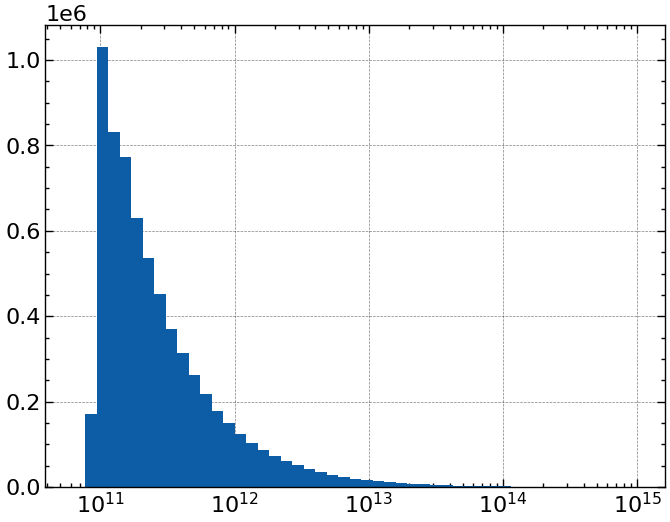

In [17]:
plt.hist(massvir[sel], bins=np.logspace(10.8, 15, 50))
plt.xscale('log')

In [12]:
edges = np.array([11.0, 12.0, 12.5, 13.0, 13.5, 14.0, 15.0])
counts, _ = np.histogram(np.log10(mass_s), bins=edges)   # mass_s = footprint+z-cut sample
for i, c in enumerate(counts):
    print(f"bin {i}  logM [{edges[i]:.1f}, {edges[i+1]:.1f}):  {c:,}")

bin 0  logM [11.0, 12.0):  5,442,933
bin 1  logM [12.0, 12.5):  489,860
bin 2  logM [12.5, 13.0):  166,203
bin 3  logM [13.0, 13.5):  54,090
bin 4  logM [13.5, 14.0):  15,357
bin 5  logM [14.0, 15.0):  3,753


In [18]:
edges = np.array([11.0, 12.0, 12.5, 13.0, 13.5, 14.0, 15.0])
counts, _ = np.histogram(np.log10(massvir), bins=edges)   # mass_s = footprint+z-cut sample
for i, c in enumerate(counts):
    print(f"bin {i}  logM [{edges[i]:.1f}, {edges[i+1]:.1f}):  {c:,}")

bin 0  logM [11.0, 12.0):  313,233,101
bin 1  logM [12.0, 12.5):  28,171,182
bin 2  logM [12.5, 13.0):  9,532,154
bin 3  logM [13.0, 13.5):  3,082,824
bin 4  logM [13.5, 14.0):  878,986
bin 5  logM [14.0, 15.0):  212,954


In [21]:
(313233101/len(massvir))*100, (28171182/len(massvir))*100, (9532154/len(massvir))*100, (3082824/len(massvir))*100, (878986/len(massvir))*100, (212954/len(massvir))*100

(81.89643080335044,
 7.365502719687314,
 2.4922314658816345,
 0.8060204416100583,
 0.22981548213231073,
 0.055677935919348095)

In [22]:
(5442933/len(mass_s))*100, (489860/len(mass_s))*100, (166203/len(mass_s))*100, (54090/len(mass_s))*100, (15357/len(mass_s))*100, (3753/len(mass_s))*100

(81.8688559998893,
 7.368137325979536,
 2.499911256256434,
 0.813584591438846,
 0.2309894355837744,
 0.05645004569550729)

In [ ]:
RAND_PATH  = '/user/animesh.sah/FP_CUTS/randoms_with_mags.fits'
MIN_SEP = 0.01           # degrees
MAX_SEP = 15.0           # degrees
NBINS   = 30             # log-spaced angular bins

NTHREADS_PER_BIN  = 30  # TreeCorr OpenMP threads per bin
MAX_PARALLEL_BINS =  8  # bins running simultaneously
ERROR       = 'jackknife'  # 'none' | 'jackknife' | 'bootstrap'
NPATCH      = 30           # spatial patches (jackknife & bootstrap)
N_BOOTSTRAP = 500          # bootstrap realisations (ERROR='bootstrap' only)
PSF_MASK = True
RAND_RATIO= 5

In [27]:
t0 = time.time()
randoms = Table(F.FITS(RAND_PATH)[1].read())
randoms = randoms[randoms['DEC'] > -30]

if PSF_MASK:
    ok = np.ones(len(randoms), dtype=bool)
    for b in ('G', 'R', 'Z'):
        ok &= randoms[f'PSFSIZE_{b}'] > 0
        ok &= randoms[f'PSFDEPTH_{b}'] > 0
    randoms = randoms[ok]
    print(f"After PSF mask: {len(randoms):,} randoms")

def subsample_footprint(randoms, photsys, n_data):
    r = randoms[randoms['PHOTSYS'] == photsys]
    keep = RAND_RATIO * n_data
    if keep < len(r):
        r = r[np.random.choice(len(r), keep, replace=False)]
    return (np.ascontiguousarray(r['RA'],  dtype=np.float64),
            np.ascontiguousarray(r['DEC'], dtype=np.float64))


RA_rF, DEC_rF = randoms['RA'], randoms['DEC']  # full randoms (for sanity check)
#del randoms


print(f"Done in {time.time()-t0:.1f}s")



After PSF mask: 75,956,942 randoms
Done in 67.6s


In [28]:
# # Shared TreeCorr config dicts
NN_KW  = dict(min_sep=MIN_SEP, max_sep=MAX_SEP, nbins=NBINS,
              sep_units='deg', bin_type='Log')
VAR_KW = {}
if ERROR == 'jackknife':
    VAR_KW = dict(var_method='jackknife', cross_patch_weight='match')
elif ERROR == 'bootstrap':
    VAR_KW = dict(var_method='bootstrap', num_bootstrap=N_BOOTSTRAP,
                  cross_patch_weight='geom')

def build_cat_rand_and_rr(ra_r, dec_r, label):
    t0 = time.time()
    kw = dict(ra=ra_r, dec=dec_r, ra_units='deg', dec_units='deg')
    if ERROR != 'none':
        kw['npatch'] = NPATCH
    cat_r = treecorr.Catalog(**kw)

    rr = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
    # Use all threads for the one-time RR computation
    rr.process(cat_r, num_threads=NTHREADS_PER_BIN * MAX_PARALLEL_BINS)
    print(f"  rr_{label} done  ({time.time()-t0:.1f}s)")
    return cat_r, rr


print('Building full random catalog + RR ...')
cat_rand_F, rr_F = build_cat_rand_and_rr(RA_rF, DEC_rF, 'F')


Building full random catalog + RR ...
  rr_F done  (146.9s)


In [ ]:
def run_wtheta_bin(label, ra_bin, dec_bin, cat_rand, rr):
    t0 = time.time()

    cat_kw = dict(ra=ra_bin, dec=dec_bin, ra_units='deg', dec_units='deg')
    if ERROR != 'none':
        cat_kw['patch_centers'] = cat_rand.patch_centers

    cat_d = treecorr.Catalog(**cat_kw)

    dd = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
    dr = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
    dd.process(cat_d,          num_threads=NTHREADS_PER_BIN)
    dr.process(cat_d, cat_rand, num_threads=NTHREADS_PER_BIN)

    xi, varxi = dd.calculateXi(rr=rr, dr=dr)
    sig = np.sqrt(np.abs(varxi))
    cov = dd.cov if ERROR != 'none' else None

    print(f"  [{label}]  N={len(ra_bin):,}  {time.time()-t0:.1f}s")
    return dict(label=label, n=len(ra_bin),
                meanr=dd.meanr, xi=xi, sig=sig, cov=cov)


def run_all_bins(bins, parallel=True):
    """
    bins : list of (label, ra, dec, weights_or_None, cat_rand, rr)
    """
    results = {}
    t0 = time.time()
    print(f"Running {len(bins)} bins  [ERROR={ERROR}, weights={USE_WEIGHTS}]")

    if parallel and len(bins) > 1:
        with ThreadPoolExecutor(max_workers=MAX_PARALLEL_BINS) as pool:
            futures = {
                pool.submit(run_wtheta_bin, lbl, ra, dec, wgt, cr, rr_): lbl
                for lbl, ra, dec, wgt, cr, rr_ in bins
            }
            for fut in as_completed(futures):
                res = fut.result()
                results[res['label']] = res
    else:
        for lbl, ra, dec, wgt, cr, rr_ in bins:
            res = run_wtheta_bin(lbl, ra, dec, wgt, cr, rr_)
            results[lbl] = res

    print(f"All bins done in {time.time()-t0:.1f}s total")
    return results


{'var_method': 'jackknife', 'cross_patch_weight': 'match'}

In [ ]:
RA_dat = ra_s
DEC_dat = dec_s
cat_kw = dict(ra=RA_dat, dec=DEC_dat, ra_units='deg', dec_units='deg')
cat_kw['patch_centers'] = cat_rand_F.patch_centers if ERROR != 'none' else None
cat_data = treecorr.Catalog(**cat_kw)
dd = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
dr = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
dd.process(cat_data, num_threads=NTHREADS_PER_BIN * MAX_PARALLEL_BINS)
dr.process(cat_data, cat_rand_F, num_threads=NTHREADS_PER_BIN * MAX_PARALLEL_BINS)
xi,varxi = dd.calculateXi(rr=rr_F, dr=dr)
sig = np.sqrt(varxi)
cov = dd.cov if ERROR != 'none' else None



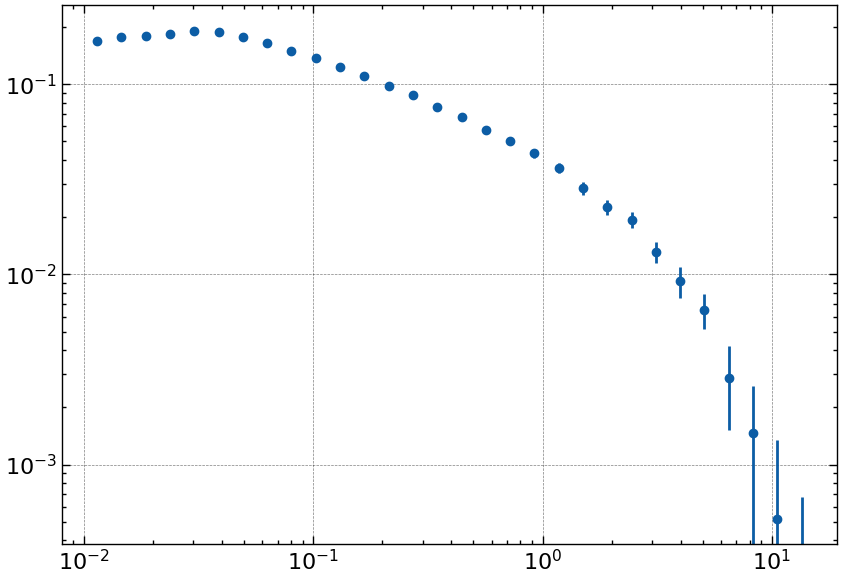

In [48]:
plt.figure(figsize=(10, 7))
plt.errorbar(dd.meanr, xi, yerr=sig, fmt='o', label='data-randoms')
plt.xscale('log')
plt.yscale('log')

In [50]:
#plt.plot(ra_s,dec_s, 'o', markersize=0.5)

In [52]:
counts

array([313233101,  28171182,   9532154,   3082824,    878986,    212954])

In [ ]:
edges = np.array([11.0, 12.0, 12.5, 13.0, 13.5, 14.0, 15.0])
counts, _ = np.histogram(np.log10(mass_s), bins=edges)   # mass_s = footprint+z-cut sample
for i, c in enumerate(counts):
    print(f"bin {i}  logM [{edges[i]:.1f}, {edges[i+1]:.1f}):  {c:,}")
    ra_sub = ra_s[(np.log10(mass_s) >= edges[i]) & (np.log10(mass_s) < edges[i+1])]
    dec_sub = dec_s[(np.log10(mass_s) >= edges[i]) & (np.log10(mass_s) < edges[i+1])]
    
    